# K7

In [1]:
# load packages and user-defined functions
options(warn=-1)
suppressPackageStartupMessages( library( DESeq2 ) )
suppressPackageStartupMessages( library( BiocParallel ) )
library(tidyverse)
library(data.table)
library("AnnotationDbi")
library("org.Hs.eg.db")
library(pathview)
library(gage)
library(gageData)
data(kegg.sets.hs)
data(sigmet.idx.hs)
library(scran)
library('glmGamPoi')
library(clusterProfiler)
library(EnhancedVolcano)
library("enrichplot")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%() masks IRanges::%within%()
✖ dplyr::collapse()     masks IRanges::collapse()
✖ dplyr::combine()      masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::count()        masks matrixStats::count()
✖ dplyr::desc()         masks IRanges::desc()
✖ tidyr::expand()       masks S4Vectors::expand()
✖ dplyr::filter()       masks stats::filter()
✖ dplyr::first()        masks S4Vectors::first()
✖ dplyr::lag()          masks stats::lag()
✖ ggplot2::Position()   masks BiocGenerics::Position(), base::Position()
✖ purrr::reduce()       masks GenomicRanges::reduce(), IRanges::reduce()
✖ dplyr::rename()       masks S4Vectors::rename()


In [2]:
suppressMessages(source("code/functions.R"))

In [3]:
reference_cells_k6_8 <- read.csv("output/reference_cells_k6-8.csv") %>% dplyr::select(experiment,cell)

In [4]:
head(reference_cells_k6_8)

,experiment,cell
,<chr>,<chr>
1,K6,AAACCTGAGACCGGAT
2,K6,AAACCTGAGGATGCGT
3,K6,AAACCTGAGGGTTTCT
4,K6,AAACCTGCAAGGCTCC
5,K6,AAACCTGCAATCCAAC
6,K6,AAACCTGCACGGTGTC


In [5]:
reference_cells_k6_8 %>%
  summarise(total_unique_cells = n_distinct(cell, experiment))

total_unique_cells
<int>
13763


In [6]:
# # seurat object (we are going to use the. non normalize counts)
 FL.integrated <- readRDS("output/FL_CLL_integrated_clean.rds")

In [7]:
#barcodes of cells group 2
cells1 <- read.csv("output/df_summary_complete.csv") %>% mutate(experiment=str_extract(subject, "^.{2}")) %>%
         mutate(cell_seurat=case_when(experiment == "K1" ~ paste0(cell,"-1_1"),
                                                           experiment == "K2" ~ paste0(cell,"-1_2"),
                                                           experiment == "K3" ~ paste0(cell,"-1_3"),
                                                           experiment == "K4" ~ paste0(cell,"-1_4"),
                                                                                             experiment == "K5" ~ paste0(cell,"-1_5"),
                                                                                             experiment == "K6" ~ paste0(cell,"-1_6"),
                                                                                             experiment == "K7" ~ paste0(cell,"-1_7"),
                                                                                             experiment == "K8" ~ paste0(cell,"-1_8"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>%
        rename("batch" = "experiment") %>% select(cell_seurat,batch) %>% unique()

In [8]:
cells1 <- cells1 %>% filter(batch %in% c("K7"))
str(cells1)

'data.frame':	125 obs. of  2 variables:
 $ cell_seurat: chr  "CAGCTAAAGTACGCGA-1_7" "TCGCGAGCATTTCAGG-1_7" "CTGCGGACAGCCTATA-1_7" "GTAACGTCATTGAGCT-1_7" ...
 $ batch      : chr  "K7" "K7" "K7" "K7" ...


In [9]:

#barcodes of cells group 1
# cells2 <- df_seq %>% filter(cell %in% trully_negative$cell) %>% mutate(experiment=str_extract(subject, "^.{2}")) %>% mutate(cell_seurat=case_when(experiment == "K4" ~ paste0(cell,"-1_1"),
#                                                                                              experiment == "K5" ~ paste0(cell,"-1_2"),
#                                                                                              experiment == "K6" ~ paste0(cell,"-1_3"),
#                                                                                              experiment == "K7" ~ paste0(cell,"-1_4"),
#                                                                                              experiment == "K8" ~ paste0(cell,"-1_5"),
#                                                                                              TRUE ~ "NA"
#                                                                                                  )) %>% filter(!cell_seurat %in% cells1) %>%
#            pull(cell_seurat) %>% unique() %>% sample(2000)

cells2 <- reference_cells_k6_8 %>% filter(experiment == "K7") %>% 
                                                                          mutate(cell_seurat=case_when(experiment == "K6" ~ paste0(cell,"-1_6"),
                                                                                             experiment == "K7" ~ paste0(cell,"-1_7"),
                                                                                             experiment == "K8" ~ paste0(cell,"-1_8"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>% 
           filter(!cell_seurat %in% cells1$cell_seurat) %>%
           rename("batch" = "experiment") %>% select(cell_seurat,batch) %>% unique()

In [10]:
cells1 %>% str()
cells2 %>% pull(cell_seurat) %>% unique() %>% str()

'data.frame':	125 obs. of  2 variables:
 $ cell_seurat: chr  "CAGCTAAAGTACGCGA-1_7" "TCGCGAGCATTTCAGG-1_7" "CTGCGGACAGCCTATA-1_7" "GTAACGTCATTGAGCT-1_7" ...
 $ batch      : chr  "K7" "K7" "K7" "K7" ...
 chr [1:4894] "AAACCTGAGAAACCGC-1_7" "AAACCTGAGACGACGT-1_7" ...


### K7

In [17]:
DEgenes <-
  # function that performs DE gene analysis
  # s     = seurat object, corrected for zeroes
  # cell1 = barcodes of cells group 1
  # cell2 = barcodes of cells group 2
  # max   = max cells per group  
  function( sObject, cells1, cells2 ){
    # subset d for cell1 and cell2, for max cells
    d <-
      bind_rows(
        cells1 %>% 
          as.data.frame() %>% 
          mutate( condition = 2 ),
        cells2 %>% 
          as.data.frame() %>% 
          mutate( condition = 1 ) ) %>%
      column_to_rownames( var = "cell_seurat" ) %>% 
      mutate( condition = factor( condition, levels = c( 1, 2 ) ) )
    
    
    # extract count table and subset for cells in colData
    cts <-
      FL.integrated@assays$RNA@counts  %>%
      as.matrix()%>% #add step
      as.data.frame() %>%
      dplyr::select( rownames( d ) ) %>%
     rownames_to_column( var = "geneName" )
    
    # remove RPL, RPS and MT- genes
    # remove RPL, RPS and MT- genes
    cts <-
      cts %>% 
       filter( 
               !geneName %like% "^RPL",
               !geneName %like% "^RPS",
               !geneName %like% "^IG[HKL][LVMCGEA]") %>%
      #         #!geneName %like% "^MT-" ) %>% 
      column_to_rownames( var = "geneName" )
    
    # are colnames in cts similarly ordered as in colData?
    if( all( rownames( d ) == colnames( cts ) ) == FALSE ){
      cts <- cts[ , rownames( d ) ]
      all( rownames( d ) == colnames( cts ) ) }
    
    # create the DESeq2 object
    dds <-
      DESeqDataSetFromMatrix( countData = cts,
                              colData   = d,
                              design    = ~ condition) # ~ batch + condition
    
    # set test and reference
    dds$cluster <-
      relevel( dds$condition, ref = "1" )
      
    
    # add genenames to the DESeq2 object
    mcols( dds ) <-
      DataFrame( mcols( dds ),
                 data.frame( gene = rownames( cts ) ) )
    
    # limit data to genes with total read count >= 1% of cell count in the data
    dds <-
      dds[ rowSums( counts( dds ) ) >= 0.01 * nrow( dds ) , ]
      
    #Estimate size factors
    dds <- estimateSizeFactors(dds, type="poscounts")
    scr <- computeSumFactors(dds)
    
    # use scran's sum factors:
    sizeFactors(dds) <- sizeFactors(scr)
    
    # run
    dds <-
      DESeq( dds,
             fitType = "glmGamPoi", #glmGamPoi
             parallel = FALSE, 
             test="LRT",
             reduced = ~ 1,
             useT=TRUE,
             minmu=1e-6,
             minReplicatesForReplace=Inf,
             BPPARAM = MulticoreParam( detectCores() ) )

    
    return( dds)
  }

dds_k7 <- DEgenes(FL.integrated, cells1, cells2)

converting counts to integer mode

using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

using 'glmGamPoi' as fitType. If used in published research, please cite:
    Ahlmann-Eltze, C., Huber, W. (2020) glmGamPoi: Fitting Gamma-Poisson
    Generalized Linear Models on Single Cell Count Data. Bioinformatics.
    https://doi.org/10.1093/bioinformatics/btaa1009

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Fit reduced model

Calculate quasi likelihood ratio

Prepare results



In [18]:
saveRDS(dds_k7, "output/DE_k7.rds")

In [19]:
# Turn the results object into a tibble for use with tidyverse functions
DE_scSHM <- results(dds_k7) %>%
        data.frame() %>%
        rownames_to_column(var="rowname") %>%
        as_tibble()

# Check results output
head(DE_scSHM)

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
NOC2L,0.32007465,-0.16192431,NA,0.78474082,0.37573708,0.7559432
ISG15,0.34628390,-0.03688492,NA,0.03616369,0.84918545,0.9622027
SDF4,0.37365627,0.09769004,NA,0.31167363,0.57667960,0.8630016
B3GALT6,0.07867035,-0.33877046,NA,0.74745264,0.38732477,0.7661493
UBE2J2,0.32770823,0.27733057,NA,2.79487723,0.09462761,0.4477008
PUSL1,0.06153629,-0.09388288,NA,0.06486992,0.79896842,0.9448726


In [20]:
write.csv( as.data.frame(DE_scSHM), file="output/DE_results_7.csv", row.names=FALSE )

In [21]:
# volcano plot
# input is table with DE genes
VolcanoPlot <-
  function( d ){
    ggplot( d %>%
   #           mutate(threshold = padj < 0.05 & abs(log2FoldChange) >= 0.58) %>%
              filter( !is.na( padj ) ),
            aes( x = log2FoldChange, y = -log10( padj )) ) +
      geom_point( size = 0.5) +
      geom_hline( yintercept = -log10( 0.05), linetype="dashed",  color = "grey" ) +
      geom_vline( xintercept = -0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      geom_vline( xintercept = 0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      ggrepel::geom_text_repel(
        data =  bind_rows( d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( log2FoldChange )  %>%
                             dplyr::slice( 1:16 ),
                           d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( desc( log2FoldChange ) ) %>%
                             dplyr::slice( 1:16 ),
                           d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( padj ) %>%
                             dplyr::slice( 1:16 ) ) %>%
          # distinct on 2 variables to keep genes
          distinct( rowname, .keep_all = TRUE) %>%
          filter( !is.na( log2FoldChange ),
                  log2FoldChange < -0.5 | log2FoldChange > 0.5),
        aes( label = rowname ), color = "red", size = 3 ) }

VolcanoPlotFixedFrame <-
  function( d ){
    # remove padj = NA
    d <-
      filter( d, !is.na( padj ) )
    # maximize coordinates for better comparison
    if( min( d$log2FoldChange ) < -2.5 ){
      d[ which( d$log2FoldChange < - 2.5 ), "log2FoldChange" ] <-
        - 1 }
    if( max( d$log2FoldChange ) > 2.5 ){
      d[ which( d$log2FoldChange > 2.5 ), "log2FoldChange" ] <-
        1 }
    if( min( d$padj ) < 1e-80 ){
      d[ which( d$padj < 1e-80 ), "padj" ] <-
        1e-80 }
    
    ggplot( d,
            aes( x = log2FoldChange, y = -log10( padj ) ) ) +
      geom_point( size = 0.5) +
      xlim( c( -2.5, 2.5 ) ) +
      ylim( c( 1, -log10( 1e-80 ) ) ) +
      geom_point( data = d %>% 
                    filter( log2FoldChange > -.5 & log2FoldChange < .5 ),
                  aes(  x = log2FoldChange, y = -log10( padj ) ), size = 0.5, color = "grey" ) +
      geom_hline( yintercept = -log10( 0.05), linetype="dashed",  color = "grey" ) +
      geom_vline( xintercept = -0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      geom_vline( xintercept = 0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      ggrepel::geom_text_repel(
        data =  bind_rows( d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( log2FoldChange )  %>%
                             dplyr::slice( 1:25 ),
                           d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( desc( log2FoldChange ) ) %>%
                             dplyr::slice( 1:25 ),
                           d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( padj ) %>%
                             dplyr::slice( 1:25 ) ) %>%
          # distinct on 2 variables to keep genes
          distinct( rowname, .keep_all = TRUE) %>%
          filter( !is.na( log2FoldChange ),
                  log2FoldChange < -0.5 | log2FoldChange > 0.5),
        aes( label = rowname ), color = "red", size = 2.5, segment.size = 0.2 )
  }

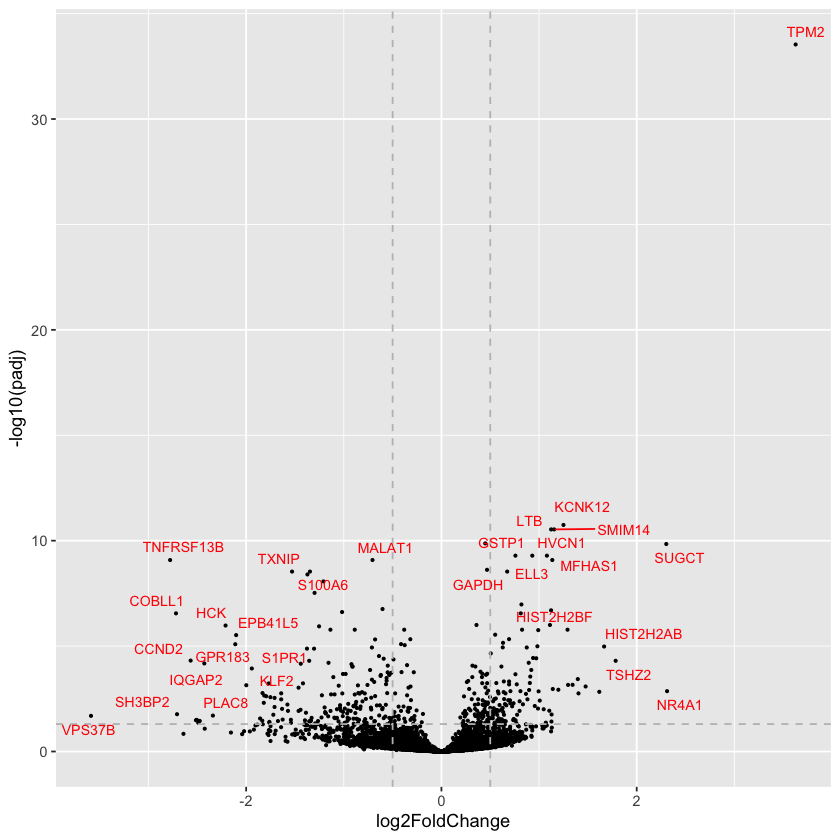

In [22]:
td <- VolcanoPlot(DE_scSHM)
td

In [23]:
fig_save(td , filename = ("figs_paper/volcano_plot_k7"), formats = c("pdf", "png"), width = 15, height =15, units = "cm", dpi = 320)

# Pathway analysis

### Convert genes names to Entrez Gene

In [24]:
DE_scSHM$entrez = mapIds(org.Hs.eg.db,
                     keys=DE_scSHM$rowname, 
                     column="ENTREZID",
                     keytype="SYMBOL",
                     multiVals="first")
DE_scSHM$name =   mapIds(org.Hs.eg.db,
                     keys=DE_scSHM$rowname, 
                     column="GENENAME",
                     keytype="SYMBOL",
                     multiVals="first")

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



In [25]:
## Remove any NA values (reduces the data by quite a bit)
DE_scSHM <- dplyr::filter(DE_scSHM, entrez != "NA")

## Remove any Entrez duplicates
DE_scSHM <- DE_scSHM[which(duplicated(DE_scSHM$entrez) == F), ]

In [26]:
DE_scSHM %>% filter(rowname == "AICDA")

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,entrez,name
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AICDA,0.3836014,0.9710243,NA,26.81508,2.325228e-07,3.790122e-05,57379,activation induced cytidine deaminase


### List of DNA repair genes

In [27]:
filename <- "input/names_genes_dna_repair.csv"
genes_names <- read.csv(filename)

In [28]:
# number of genes analysed
length(genes_names$gene)

[1] 66

In [29]:
DE_scSHM %>% filter(rowname %in% genes_names$gene, padj < 0.05)  %>% arrange(rowname) 

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,entrez,name
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AICDA,0.3836014,0.9710243,NA,26.81508,2.325228e-07,3.790122e-05,57379,activation induced cytidine deaminase
MBD4,0.8790885,0.4147775,NA,12.32872,4.499195e-04,1.522086e-02,8930,"methyl-CpG binding domain 4, DNA glycosylase"
PARP1,3.3989775,0.2819793,NA,13.57332,2.318112e-04,9.319228e-03,142,poly(ADP-ribose) polymerase 1
PARP3,0.1357873,-1.0970765,NA,11.15174,8.455800e-04,2.477328e-02,10039,poly(ADP-ribose) polymerase family member 3
POLD4,2.0257254,0.5052982,NA,27.95870,1.291246e-07,2.226158e-05,57804,"DNA polymerase delta 4, accessory subunit"
RPA2,0.4666712,0.4766176,NA,12.21546,4.779988e-04,1.569692e-02,6118,replication protein A2


## 1) Generally Applicable Gene-set Enrichment for Pathway Analysis: gage

In [30]:
kegg.sets.hs = kegg.sets.hs[sigmet.idx.hs]

In [31]:
## Extract the foldchanges
foldchanges = DE_scSHM$log2FoldChange

## Name each fold change with the corresponding Entrez ID
names(foldchanges) = DE_scSHM$entrez
head(foldchanges)

26155        9636       51150      126792      118424      126789 
-0.16192431 -0.03688492  0.09769004 -0.33877046  0.27733057 -0.09388288

In [32]:
## Sort fold changes in decreasing order
foldchanges <- sort(foldchanges, decreasing = TRUE)

In [33]:
#saveRDS(foldchanges, file = "foldchanges_v2.rds")

In [34]:
# Get the results
keggres = gage(foldchanges, gsets=kegg.sets.hs, same.dir=TRUE)

# Look at both up (greater), down (less), and statatistics.
lapply(keggres, head,12)

,p.geomean,stat.mean,p.val,q.val,set.size,exp1
hsa00190 Oxidative phosphorylation,0.001807289,2.963564,0.001807289,0.1896547,101,0.001807289
hsa04114 Oocyte meiosis,0.002768682,2.822116,0.002768682,0.1896547,76,0.002768682
hsa03030 DNA replication,0.005370393,2.640850,0.005370393,0.2452479,34,0.005370393
hsa03040 Spliceosome,0.012563586,2.259434,0.012563586,0.4138679,122,0.012563586
hsa04110 Cell cycle,0.017551542,2.120923,0.017551542,0.4138679,106,0.017551542
hsa04914 Progesterone-mediated oocyte maturation,0.018125604,2.126935,0.018125604,0.4138679,55,0.018125604
hsa03430 Mismatch repair,0.023666437,2.065064,0.023666437,0.4631860,22,0.023666437
hsa03440 Homologous recombination,0.039947893,1.798130,0.039947893,0.6326163,22,0.039947893
hsa04370 VEGF signaling pathway,0.041558735,1.755765,0.041558735,0.6326163,43,0.041558735
hsa04530 Tight junction,0.074213877,1.456755,0.074213877,0.8874341,55,0.074213877


In [35]:
# Get the pathways
keggrespathways = data.frame(id=rownames(keggres$greater), keggres$greater) %>% 
  tbl_df() %>% 
  filter(row_number()<=5) %>% 
  .$id %>% 
  as.character()
keggrespathways

[1] "hsa00190 Oxidative phosphorylation" "hsa04114 Oocyte meiosis"           
[3] "hsa03030 DNA replication"           "hsa03040 Spliceosome"              
[5] "hsa04110 Cell cycle"

In [36]:
# Get the IDs.
keggresids = substr(keggrespathways, start=1, stop=8)
keggresids

[1] "hsa00190" "hsa04114" "hsa03030" "hsa03040" "hsa04110"